# 실전 데이터분석
- 서울시 자치구 년도별 CCTV 현황
- 서울시 주민등록인구(구별) 현황

### 서울시 자치구 년도별 CCTV 현황

In [2]:
import numpy as np
import pandas as pd

In [5]:
# !pip install openpyxl : 엑셀 파일 읽을 수 있는 모듈이 없다고 나올 때 이용.
CCTV = pd.read_excel('CCTV.xlsx')
# 실제 파일과의 index와 column이 다름 주의.
CCTV

,Unnamed: 0,서울시 자치구 (연도별) CCTV 설치 현황,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,Unnamed: 10,Unnamed: 11,Unnamed: 12
0,NaN,"(단위 : 대, '25. 12. 31. 기준)",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,자치구,총 계,2016년 이전,2017년,2018년,2019년,2020년,2021년,2022년,2023년,2024년,2025년
2,NaN,계,122613,15219,9222,10188,12635,11384,9390,9014,13935,20270,11356
3,NaN,종로구,3125,38,55,115,45,223,85,225,1026,1041,272
4,NaN,중 구,3427,388,366,384,162,352,404,137,138,582,514
5,NaN,용산구,3801,105,98,65,317,563,400,446,385,649,773
6,NaN,성동구,4790,507,924,454,688,480,361,231,488,368,289
7,NaN,광진구,4872,60,652,464,637,194,739,277,348,1015,486
8,NaN,동대문구,4305,1586,143,195,211,224,181,234,509,572,450
9,NaN,중랑구,5549,337,179,208,1056,987,603,348,689,895,247


In [7]:
CCTV = pd.read_excel('CCTV.xlsx', skiprows=2) # 위에서 두 줄(열)을 넘기고 세 번째부터 읽기.
CCTV

,Unnamed: 0,자치구,총 계,2016년 이전,2017년,2018년,2019년,2020년,2021년,2022년,2023년,2024년,2025년
0,NaN,계,122613.0,15219.0,9222.0,10188.0,12635.0,11384.0,9390.0,9014.0,13935.0,20270.0,11356.0
1,NaN,종로구,3125.0,38.0,55.0,115.0,45.0,223.0,85.0,225.0,1026.0,1041.0,272.0
2,NaN,중 구,3427.0,388.0,366.0,384.0,162.0,352.0,404.0,137.0,138.0,582.0,514.0
3,NaN,용산구,3801.0,105.0,98.0,65.0,317.0,563.0,400.0,446.0,385.0,649.0,773.0
4,NaN,성동구,4790.0,507.0,924.0,454.0,688.0,480.0,361.0,231.0,488.0,368.0,289.0
5,NaN,광진구,4872.0,60.0,652.0,464.0,637.0,194.0,739.0,277.0,348.0,1015.0,486.0
6,NaN,동대문구,4305.0,1586.0,143.0,195.0,211.0,224.0,181.0,234.0,509.0,572.0,450.0
7,NaN,중랑구,5549.0,337.0,179.0,208.0,1056.0,987.0,603.0,348.0,689.0,895.0,247.0
8,NaN,성북구,5304.0,515.0,294.0,707.0,632.0,202.0,370.0,337.0,405.0,1065.0,777.0
9,NaN,강북구,4598.0,170.0,1.0,294.0,919.0,533.0,384.0,633.0,370.0,836.0,458.0


In [9]:
CCTV.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27 entries, 0 to 26
Data columns (total 13 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  0 non-null      float64
 1   자치구         27 non-null     object 
 2   총 계         26 non-null     float64
 3   2016년 이전    26 non-null     float64
 4   2017년       26 non-null     float64
 5   2018년       26 non-null     float64
 6   2019년       26 non-null     float64
 7   2020년       26 non-null     float64
 8   2021년       26 non-null     float64
 9   2022년       26 non-null     float64
 10  2023년       26 non-null     float64
 11  2024년       26 non-null     float64
 12  2025년       26 non-null     float64
dtypes: float64(12), object(1)
memory usage: 2.9+ KB


In [10]:
del CCTV['Unnamed: 0'] # 열 삭제.
CCTV

,자치구,총 계,2016년 이전,2017년,2018년,2019년,2020년,2021년,2022년,2023년,2024년,2025년
0,계,122613.0,15219.0,9222.0,10188.0,12635.0,11384.0,9390.0,9014.0,13935.0,20270.0,11356.0
1,종로구,3125.0,38.0,55.0,115.0,45.0,223.0,85.0,225.0,1026.0,1041.0,272.0
2,중 구,3427.0,388.0,366.0,384.0,162.0,352.0,404.0,137.0,138.0,582.0,514.0
3,용산구,3801.0,105.0,98.0,65.0,317.0,563.0,400.0,446.0,385.0,649.0,773.0
4,성동구,4790.0,507.0,924.0,454.0,688.0,480.0,361.0,231.0,488.0,368.0,289.0
5,광진구,4872.0,60.0,652.0,464.0,637.0,194.0,739.0,277.0,348.0,1015.0,486.0
6,동대문구,4305.0,1586.0,143.0,195.0,211.0,224.0,181.0,234.0,509.0,572.0,450.0
7,중랑구,5549.0,337.0,179.0,208.0,1056.0,987.0,603.0,348.0,689.0,895.0,247.0
8,성북구,5304.0,515.0,294.0,707.0,632.0,202.0,370.0,337.0,405.0,1065.0,777.0
9,강북구,4598.0,170.0,1.0,294.0,919.0,533.0,384.0,633.0,370.0,836.0,458.0


In [12]:
CCTV.drop(26, inplace=True) # 행 삭제. 
# inplace 기본값은 False : 내부에서 작용. 원본에 적용됨.

KeyError: '[26] not found in axis'

In [15]:
CCTV.drop(0, inplace=True)

KeyError: '[0] not found in axis'

In [17]:
CCTV

,자치구,총 계,2016년 이전,2017년,2018년,2019년,2020년,2021년,2022년,2023년,2024년,2025년
1,종로구,3125.0,38.0,55.0,115.0,45.0,223.0,85.0,225.0,1026.0,1041.0,272.0
2,중 구,3427.0,388.0,366.0,384.0,162.0,352.0,404.0,137.0,138.0,582.0,514.0
3,용산구,3801.0,105.0,98.0,65.0,317.0,563.0,400.0,446.0,385.0,649.0,773.0
4,성동구,4790.0,507.0,924.0,454.0,688.0,480.0,361.0,231.0,488.0,368.0,289.0
5,광진구,4872.0,60.0,652.0,464.0,637.0,194.0,739.0,277.0,348.0,1015.0,486.0
6,동대문구,4305.0,1586.0,143.0,195.0,211.0,224.0,181.0,234.0,509.0,572.0,450.0
7,중랑구,5549.0,337.0,179.0,208.0,1056.0,987.0,603.0,348.0,689.0,895.0,247.0
8,성북구,5304.0,515.0,294.0,707.0,632.0,202.0,370.0,337.0,405.0,1065.0,777.0
9,강북구,4598.0,170.0,1.0,294.0,919.0,533.0,384.0,633.0,370.0,836.0,458.0
10,도봉구,3114.0,4.0,22.0,127.0,144.0,151.0,542.0,527.0,643.0,582.0,372.0


In [16]:
CCTV.tail(2)

,자치구,총 계,2016년 이전,2017년,2018년,2019년,2020년,2021년,2022년,2023년,2024년,2025년
24,송파구,5002.0,303.0,227.0,516.0,1052.0,260.0,175.0,373.0,941.0,747.0,408.0
25,강동구,4918.0,927.0,273.0,377.0,356.0,614.0,262.0,381.0,359.0,688.0,681.0


In [18]:
CCTV.sort_values('총 계', ascending=False)

,자치구,총 계,2016년 이전,2017년,2018년,2019년,2020년,2021년,2022년,2023년,2024년,2025년
23,강남구,8600.0,1741.0,918.0,726.0,807.0,671.0,501.0,603.0,912.0,610.0,1111.0
21,관악구,7202.0,480.0,639.0,662.0,886.0,400.0,550.0,137.0,745.0,1067.0,1636.0
22,서초구,6377.0,1178.0,1019.0,416.0,332.0,415.0,565.0,882.0,469.0,744.0,357.0
12,은평구,5883.0,730.0,361.0,593.0,1062.0,441.0,567.0,503.0,462.0,882.0,282.0
17,구로구,5881.0,270.0,535.0,534.0,784.0,749.0,684.0,336.0,484.0,1318.0,187.0
7,중랑구,5549.0,337.0,179.0,208.0,1056.0,987.0,603.0,348.0,689.0,895.0,247.0
19,영등포구,5450.0,1511.0,311.0,657.0,65.0,1217.0,283.0,346.0,198.0,547.0,315.0
8,성북구,5304.0,515.0,294.0,707.0,632.0,202.0,370.0,337.0,405.0,1065.0,777.0
15,양천구,5066.0,410.0,557.0,823.0,323.0,349.0,357.0,387.0,994.0,588.0,278.0
24,송파구,5002.0,303.0,227.0,516.0,1052.0,260.0,175.0,373.0,941.0,747.0,408.0


## CCTV 최근 증가율
최근증가율 = (2025+2024+2023) / 총 계 * 100

In [22]:
CCTV['최근증가율'] = 20 # 새로운 column 추가

In [23]:
CCTV.head(2)

,자치구,총 계,2016년 이전,2017년,2018년,2019년,2020년,2021년,2022년,2023년,2024년,2025년,최근증가율
1,종로구,3125.0,38.0,55.0,115.0,45.0,223.0,85.0,225.0,1026.0,1041.0,272.0,20
2,중 구,3427.0,388.0,366.0,384.0,162.0,352.0,404.0,137.0,138.0,582.0,514.0,20


In [24]:
CCTV['최근증가율'] = (CCTV['2025년']+CCTV['2024년']+CCTV['2023년'])/CCTV['총 계']*100 
# 자동으로 colums들의 index 항목에 대한 1차원 배열을 만듦.

In [25]:
CCTV

,자치구,총 계,2016년 이전,2017년,2018년,2019년,2020년,2021년,2022년,2023년,2024년,2025년,최근증가율
1,종로구,3125.0,38.0,55.0,115.0,45.0,223.0,85.0,225.0,1026.0,1041.0,272.0,74.848000
2,중 구,3427.0,388.0,366.0,384.0,162.0,352.0,404.0,137.0,138.0,582.0,514.0,36.008170
3,용산구,3801.0,105.0,98.0,65.0,317.0,563.0,400.0,446.0,385.0,649.0,773.0,47.540121
4,성동구,4790.0,507.0,924.0,454.0,688.0,480.0,361.0,231.0,488.0,368.0,289.0,23.903967
5,광진구,4872.0,60.0,652.0,464.0,637.0,194.0,739.0,277.0,348.0,1015.0,486.0,37.951560
6,동대문구,4305.0,1586.0,143.0,195.0,211.0,224.0,181.0,234.0,509.0,572.0,450.0,35.563298
7,중랑구,5549.0,337.0,179.0,208.0,1056.0,987.0,603.0,348.0,689.0,895.0,247.0,32.996936
8,성북구,5304.0,515.0,294.0,707.0,632.0,202.0,370.0,337.0,405.0,1065.0,777.0,42.364253
9,강북구,4598.0,170.0,1.0,294.0,919.0,533.0,384.0,633.0,370.0,836.0,458.0,36.189648
10,도봉구,3114.0,4.0,22.0,127.0,144.0,151.0,542.0,527.0,643.0,582.0,372.0,51.284522


In [27]:
CCTV.sort_values('최근증가율', ascending=False)

,자치구,총 계,2016년 이전,2017년,2018년,2019년,2020년,2021년,2022년,2023년,2024년,2025년,최근증가율
1,종로구,3125.0,38.0,55.0,115.0,45.0,223.0,85.0,225.0,1026.0,1041.0,272.0,74.848000
10,도봉구,3114.0,4.0,22.0,127.0,144.0,151.0,542.0,527.0,643.0,582.0,372.0,51.284522
11,노원구,4238.0,654.0,153.0,205.0,315.0,378.0,213.0,161.0,619.0,1338.0,202.0,50.943841
20,동작구,4182.0,434.0,208.0,300.0,312.0,429.0,31.0,358.0,439.0,1348.0,323.0,50.454328
18,금천구,3986.0,17.0,109.0,517.0,368.0,511.0,207.0,304.0,824.0,747.0,382.0,48.996488
21,관악구,7202.0,480.0,639.0,662.0,886.0,400.0,550.0,137.0,745.0,1067.0,1636.0,47.875590
3,용산구,3801.0,105.0,98.0,65.0,317.0,563.0,400.0,446.0,385.0,649.0,773.0,47.540121
8,성북구,5304.0,515.0,294.0,707.0,632.0,202.0,370.0,337.0,405.0,1065.0,777.0,42.364253
24,송파구,5002.0,303.0,227.0,516.0,1052.0,260.0,175.0,373.0,941.0,747.0,408.0,41.903239
16,강서구,4588.0,310.0,398.0,257.0,454.0,361.0,435.0,604.0,429.0,1057.0,283.0,38.557105


### 주민등록인구(구별) 현황

In [34]:
POP = pd.read_excel('POP.xlsx') # colum에 같은 항목이 올 수 없다.
POP

C:\ProgramData\anaconda3\Lib\site-packages\openpyxl\styles\stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")


,동별(1),동별(2),2026. 05,2026. 05.1,2026. 05.2,2026. 05.3,2026. 05.4,2026. 05.5,2026. 05.6,2026. 05.7,2026. 05.8
0,동별(1),동별(2),합계 (명),합계 (명),합계 (명),한국인 (명),한국인 (명),한국인 (명),외국인 (명),외국인 (명),외국인 (명)
1,동별(1),동별(2),소계,남자,여자,소계,남자,여자,소계,남자,여자
2,합계,소계,9567749,4590491,4977258,9295082,4475263,4819819,272667,115228,157439
3,NaN,종로구,148154,70357,77797,136518,65362,71156,11636,4995,6641
4,NaN,중구,128234,61363,66871,117765,56536,61229,10469,4827,5642
5,NaN,용산구,212356,101254,111102,199810,94881,104929,12546,6373,6173
6,NaN,성동구,282757,135813,146944,274694,132408,142286,8063,3405,4658
7,NaN,광진구,348902,165508,183394,331136,158341,172795,17766,7167,10599
8,NaN,동대문구,373181,179059,194122,352299,171585,180714,20882,7474,13408
9,NaN,중랑구,383396,186611,196785,376463,183671,192792,6933,2940,3993


In [36]:
POP = pd.read_excel('POP.xlsx', skiprows=1)
POP

C:\ProgramData\anaconda3\Lib\site-packages\openpyxl\styles\stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")


,동별(1),동별(2),합계 (명),합계 (명).1,합계 (명).2,한국인 (명),한국인 (명).1,한국인 (명).2,외국인 (명),외국인 (명).1,외국인 (명).2
0,동별(1),동별(2),소계,남자,여자,소계,남자,여자,소계,남자,여자
1,합계,소계,9567749,4590491,4977258,9295082,4475263,4819819,272667,115228,157439
2,NaN,종로구,148154,70357,77797,136518,65362,71156,11636,4995,6641
3,NaN,중구,128234,61363,66871,117765,56536,61229,10469,4827,5642
4,NaN,용산구,212356,101254,111102,199810,94881,104929,12546,6373,6173
5,NaN,성동구,282757,135813,146944,274694,132408,142286,8063,3405,4658
6,NaN,광진구,348902,165508,183394,331136,158341,172795,17766,7167,10599
7,NaN,동대문구,373181,179059,194122,352299,171585,180714,20882,7474,13408
8,NaN,중랑구,383396,186611,196785,376463,183671,192792,6933,2940,3993
9,NaN,성북구,437253,206928,230325,422190,201401,220789,15063,5527,9536


In [38]:
POP.columns
# 동별(2), 한국인(명), 외국인(명)만 필요.

Index(['동별(1)', '동별(2)', '합계 (명)', '합계 (명).1', '합계 (명).2', '한국인 (명)',
       '한국인 (명).1', '한국인 (명).2', '외국인 (명)', '외국인 (명).1', '외국인 (명).2'],
      dtype='object')

In [40]:
POP = pd.read_excel('POP.xlsx', skiprows=[0,2,3], usecols=['동별(2)', '한국인 (명)', '외국인 (명)'])
POP

C:\ProgramData\anaconda3\Lib\site-packages\openpyxl\styles\stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")


,동별(2),한국인 (명),외국인 (명)
0,종로구,136518,11636
1,중구,117765,10469
2,용산구,199810,12546
3,성동구,274694,8063
4,광진구,331136,17766
5,동대문구,352299,20882
6,중랑구,376463,6933
7,성북구,422190,15063
8,강북구,278294,7252
9,도봉구,298571,3208


In [41]:
POP.columns

Index(['동별(2)', '한국인 (명)', '외국인 (명)'], dtype='object')

In [42]:
POP.columns = ['구별', '한국인', '외국인'] # 기존 columns 개수 맞아야 함.

In [45]:
POP.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25 entries, 0 to 24
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   구별      25 non-null     object
 1   한국인     25 non-null     int64 
 2   외국인     25 non-null     int64 
dtypes: int64(2), object(1)
memory usage: 732.0+ bytes


In [46]:
POP['인구수'] = POP['한국인'] + POP['외국인']

In [47]:
POP.head(2)

,구별,한국인,외국인,인구수
0,종로구,136518,11636,148154
1,중구,117765,10469,128234


In [48]:
POP['외국인비율'] = POP['외국인'] / POP['인구수'] * 100

In [50]:
POP

,구별,한국인,외국인,인구수,외국인비율
0,종로구,136518,11636,148154,7.853990
1,중구,117765,10469,128234,8.163981
2,용산구,199810,12546,212356,5.908004
3,성동구,274694,8063,282757,2.851565
4,광진구,331136,17766,348902,5.091974
5,동대문구,352299,20882,373181,5.595676
6,중랑구,376463,6933,383396,1.808313
7,성북구,422190,15063,437253,3.444916
8,강북구,278294,7252,285546,2.539696
9,도봉구,298571,3208,301779,1.063030


In [53]:
POP.columns

Index(['구별', '한국인', '외국인', '인구수', '외국인비율'], dtype='object')

In [54]:
CCTV.columns

Index(['자치구', '총 계', '2016년 이전', '2017년', '2018년', '2019년', '2020년', '2021년',
       '2022년', '2023년', '2024년', '2025년', '최근증가율'],
      dtype='object')

In [55]:
CCTV.rename(columns={'자치구':'구별', '총 계':'CCTV총계'}, inplace=True)

In [56]:
CCTV.columns

Index(['구별', 'CCTV총계', '2016년 이전', '2017년', '2018년', '2019년', '2020년', '2021년',
       '2022년', '2023년', '2024년', '2025년', '최근증가율'],
      dtype='object')

In [57]:
CCTV_POP = pd.merge(CCTV, POP, on='구별')

In [58]:
CCTV_POP

,구별,CCTV총계,2016년 이전,2017년,2018년,2019년,2020년,2021년,2022년,2023년,2024년,2025년,최근증가율,한국인,외국인,인구수,외국인비율
0,종로구,3125.0,38.0,55.0,115.0,45.0,223.0,85.0,225.0,1026.0,1041.0,272.0,74.848000,136518,11636,148154,7.853990
1,용산구,3801.0,105.0,98.0,65.0,317.0,563.0,400.0,446.0,385.0,649.0,773.0,47.540121,199810,12546,212356,5.908004
2,성동구,4790.0,507.0,924.0,454.0,688.0,480.0,361.0,231.0,488.0,368.0,289.0,23.903967,274694,8063,282757,2.851565
3,광진구,4872.0,60.0,652.0,464.0,637.0,194.0,739.0,277.0,348.0,1015.0,486.0,37.951560,331136,17766,348902,5.091974
4,동대문구,4305.0,1586.0,143.0,195.0,211.0,224.0,181.0,234.0,509.0,572.0,450.0,35.563298,352299,20882,373181,5.595676
5,중랑구,5549.0,337.0,179.0,208.0,1056.0,987.0,603.0,348.0,689.0,895.0,247.0,32.996936,376463,6933,383396,1.808313
6,성북구,5304.0,515.0,294.0,707.0,632.0,202.0,370.0,337.0,405.0,1065.0,777.0,42.364253,422190,15063,437253,3.444916
7,강북구,4598.0,170.0,1.0,294.0,919.0,533.0,384.0,633.0,370.0,836.0,458.0,36.189648,278294,7252,285546,2.539696
8,도봉구,3114.0,4.0,22.0,127.0,144.0,151.0,542.0,527.0,643.0,582.0,372.0,51.284522,298571,3208,301779,1.063030
9,노원구,4238.0,654.0,153.0,205.0,315.0,378.0,213.0,161.0,619.0,1338.0,202.0,50.943841,481589,5460,487049,1.121037


In [61]:
CCTV['구별']

1      종로구
2      중 구
3      용산구
4      성동구
5      광진구
6     동대문구
7      중랑구
8      성북구
9      강북구
10     도봉구
11     노원구
12     은평구
13    서대문구
14     마포구
15     양천구
16     강서구
17     구로구
18     금천구
19    영등포구
20     동작구
21     관악구
22     서초구
23     강남구
24     송파구
25     강동구
Name: 구별, dtype: object

In [62]:
POP['구별']

0      종로구
1       중구
2      용산구
3      성동구
4      광진구
5     동대문구
6      중랑구
7      성북구
8      강북구
9      도봉구
10     노원구
11     은평구
12    서대문구
13     마포구
14     양천구
15     강서구
16     구로구
17     금천구
18    영등포구
19     동작구
20     관악구
21     서초구
22     강남구
23     송파구
24     강동구
Name: 구별, dtype: object

In [63]:
CCTV.iloc[1,0]

'중 구'

In [64]:
CCTV.iloc[1,0] = '중구'

In [65]:
CCTV['구별']

1      종로구
2       중구
3      용산구
4      성동구
5      광진구
6     동대문구
7      중랑구
8      성북구
9      강북구
10     도봉구
11     노원구
12     은평구
13    서대문구
14     마포구
15     양천구
16     강서구
17     구로구
18     금천구
19    영등포구
20     동작구
21     관악구
22     서초구
23     강남구
24     송파구
25     강동구
Name: 구별, dtype: object

In [66]:
CCTV_POP = pd.merge(CCTV, POP, on='구별')

In [67]:
CCTV_POP

,구별,CCTV총계,2016년 이전,2017년,2018년,2019년,2020년,2021년,2022년,2023년,2024년,2025년,최근증가율,한국인,외국인,인구수,외국인비율
0,종로구,3125.0,38.0,55.0,115.0,45.0,223.0,85.0,225.0,1026.0,1041.0,272.0,74.848000,136518,11636,148154,7.853990
1,중구,3427.0,388.0,366.0,384.0,162.0,352.0,404.0,137.0,138.0,582.0,514.0,36.008170,117765,10469,128234,8.163981
2,용산구,3801.0,105.0,98.0,65.0,317.0,563.0,400.0,446.0,385.0,649.0,773.0,47.540121,199810,12546,212356,5.908004
3,성동구,4790.0,507.0,924.0,454.0,688.0,480.0,361.0,231.0,488.0,368.0,289.0,23.903967,274694,8063,282757,2.851565
4,광진구,4872.0,60.0,652.0,464.0,637.0,194.0,739.0,277.0,348.0,1015.0,486.0,37.951560,331136,17766,348902,5.091974
5,동대문구,4305.0,1586.0,143.0,195.0,211.0,224.0,181.0,234.0,509.0,572.0,450.0,35.563298,352299,20882,373181,5.595676
6,중랑구,5549.0,337.0,179.0,208.0,1056.0,987.0,603.0,348.0,689.0,895.0,247.0,32.996936,376463,6933,383396,1.808313
7,성북구,5304.0,515.0,294.0,707.0,632.0,202.0,370.0,337.0,405.0,1065.0,777.0,42.364253,422190,15063,437253,3.444916
8,강북구,4598.0,170.0,1.0,294.0,919.0,533.0,384.0,633.0,370.0,836.0,458.0,36.189648,278294,7252,285546,2.539696
9,도봉구,3114.0,4.0,22.0,127.0,144.0,151.0,542.0,527.0,643.0,582.0,372.0,51.284522,298571,3208,301779,1.063030


In [69]:
CCTV_POP.loc[22] # 행 선택.

구별                강남구
CCTV총계         8600.0
2016년 이전       1741.0
2017년           918.0
2018년           726.0
2019년           807.0
2020년           671.0
2021년           501.0
2022년           603.0
2023년           912.0
2024년           610.0
2025년          1111.0
최근증가율       30.616279
한국인            552962
외국인              6171
인구수            559133
외국인비율        1.103673
Name: 22, dtype: object

In [70]:
CCTV_POP.set_index('구별', inplace=True) # '구별' column을 index로 지정.

In [71]:
CCTV_POP

,CCTV총계,2016년 이전,2017년,2018년,2019년,2020년,2021년,2022년,2023년,2024년,2025년,최근증가율,한국인,외국인,인구수,외국인비율
구별,,,,,,,,,,,,,,,,
종로구,3125.0,38.0,55.0,115.0,45.0,223.0,85.0,225.0,1026.0,1041.0,272.0,74.848000,136518,11636,148154,7.853990
중구,3427.0,388.0,366.0,384.0,162.0,352.0,404.0,137.0,138.0,582.0,514.0,36.008170,117765,10469,128234,8.163981
용산구,3801.0,105.0,98.0,65.0,317.0,563.0,400.0,446.0,385.0,649.0,773.0,47.540121,199810,12546,212356,5.908004
성동구,4790.0,507.0,924.0,454.0,688.0,480.0,361.0,231.0,488.0,368.0,289.0,23.903967,274694,8063,282757,2.851565
광진구,4872.0,60.0,652.0,464.0,637.0,194.0,739.0,277.0,348.0,1015.0,486.0,37.951560,331136,17766,348902,5.091974
동대문구,4305.0,1586.0,143.0,195.0,211.0,224.0,181.0,234.0,509.0,572.0,450.0,35.563298,352299,20882,373181,5.595676
중랑구,5549.0,337.0,179.0,208.0,1056.0,987.0,603.0,348.0,689.0,895.0,247.0,32.996936,376463,6933,383396,1.808313
성북구,5304.0,515.0,294.0,707.0,632.0,202.0,370.0,337.0,405.0,1065.0,777.0,42.364253,422190,15063,437253,3.444916
강북구,4598.0,170.0,1.0,294.0,919.0,533.0,384.0,633.0,370.0,836.0,458.0,36.189648,278294,7252,285546,2.539696


In [73]:
CCTV_POP.loc['관악구']

CCTV총계        7202.000000
2016년 이전       480.000000
2017년          639.000000
2018년          662.000000
2019년          886.000000
2020년          400.000000
2021년          550.000000
2022년          137.000000
2023년          745.000000
2024년         1067.000000
2025년         1636.000000
최근증가율           47.875590
한국인         478154.000000
외국인          19774.000000
인구수         497928.000000
외국인비율            3.971257
Name: 관악구, dtype: float64

In [74]:
CCTV_POP.loc['강남구']

CCTV총계        8600.000000
2016년 이전      1741.000000
2017년          918.000000
2018년          726.000000
2019년          807.000000
2020년          671.000000
2021년          501.000000
2022년          603.000000
2023년          912.000000
2024년          610.000000
2025년         1111.000000
최근증가율           30.616279
한국인         552962.000000
외국인           6171.000000
인구수         559133.000000
외국인비율            1.103673
Name: 강남구, dtype: float64

# 상관관계 분석
상관계수 : -1 ~ +1  
0.1 이하 : 관계 없음, 무시  
0.3 이하 : 약한 상관 관계  
0.7 이하 : 뚜렷한 상관 관계  
1.0 이하 : 아주 높은 상관 관계

In [75]:
np.corrcoef(CCTV_POP['외국인비율'], CCTV_POP['CCTV총계'])

array([[ 1.       , -0.3835896],
       [-0.3835896,  1.       ]])

In [76]:
np.corrcoef(CCTV_POP['외국인'], CCTV_POP['CCTV총계'])

array([[1.        , 0.03690735],
       [0.03690735, 1.        ]])

In [77]:
np.corrcoef(CCTV_POP['인구수'], CCTV_POP['CCTV총계'])

array([[1.        , 0.62161358],
       [0.62161358, 1.        ]])

In [78]:
CCTV_POP['인구수대비CCTV비율'] = CCTV_POP['CCTV총계'] / CCTV_POP['인구수'] * 100

In [80]:
np.corrcoef(CCTV_POP['최근증가율'], CCTV_POP['인구수대비CCTV비율'])

array([[1.        , 0.07816531],
       [0.07816531, 1.        ]])

In [82]:
import matplotlib.pyplot as plt
# 기본 폰트가 영어 폰트여서 한국어 폰트에 대해 문제가 있음.
plt.rcParams['font.family'] = 'New Gulim'
plt.rcParams['font.size'] = 12
plt.rcParams['axes.unicode_minus'] = False

In [83]:
CCTV_POP['CCTV총계'].sort_values(ascending=False)

구별
강남구     8600.0
관악구     7202.0
서초구     6377.0
은평구     5883.0
구로구     5881.0
중랑구     5549.0
영등포구    5450.0
성북구     5304.0
양천구     5066.0
송파구     5002.0
강동구     4918.0
광진구     4872.0
성동구     4790.0
강북구     4598.0
강서구     4588.0
서대문구    4305.0
동대문구    4305.0
노원구     4238.0
동작구     4182.0
마포구     4050.0
금천구     3986.0
용산구     3801.0
중구      3427.0
종로구     3125.0
도봉구     3114.0
Name: CCTV총계, dtype: float64

In [84]:
CCTV_POP.sort_values('CCTV총계', ascending=False) # 'CCTV총계' columns를 기준(axis)으로 정렬

,CCTV총계,2016년 이전,2017년,2018년,2019년,2020년,2021년,2022년,2023년,2024년,2025년,최근증가율,한국인,외국인,인구수,외국인비율,인구수대비CCTV비율
구별,,,,,,,,,,,,,,,,,
강남구,8600.0,1741.0,918.0,726.0,807.0,671.0,501.0,603.0,912.0,610.0,1111.0,30.616279,552962,6171,559133,1.103673,1.538096
관악구,7202.0,480.0,639.0,662.0,886.0,400.0,550.0,137.0,745.0,1067.0,1636.0,47.875590,478154,19774,497928,3.971257,1.446394
서초구,6377.0,1178.0,1019.0,416.0,332.0,415.0,565.0,882.0,469.0,744.0,357.0,24.619727,414486,4930,419416,1.175444,1.520447
은평구,5883.0,730.0,361.0,593.0,1062.0,441.0,567.0,503.0,462.0,882.0,282.0,27.638960,453398,4502,457900,0.983184,1.284778
구로구,5881.0,270.0,535.0,534.0,784.0,749.0,684.0,336.0,484.0,1318.0,187.0,33.820779,382652,22148,404800,5.471344,1.452816
중랑구,5549.0,337.0,179.0,208.0,1056.0,987.0,603.0,348.0,689.0,895.0,247.0,32.996936,376463,6933,383396,1.808313,1.447329
영등포구,5450.0,1511.0,311.0,657.0,65.0,1217.0,283.0,346.0,198.0,547.0,315.0,19.449541,371772,21546,393318,5.478010,1.385647
성북구,5304.0,515.0,294.0,707.0,632.0,202.0,370.0,337.0,405.0,1065.0,777.0,42.364253,422190,15063,437253,3.444916,1.213028
양천구,5066.0,410.0,557.0,823.0,323.0,349.0,357.0,387.0,994.0,588.0,278.0,36.715357,422070,3319,425389,0.780227,1.190910


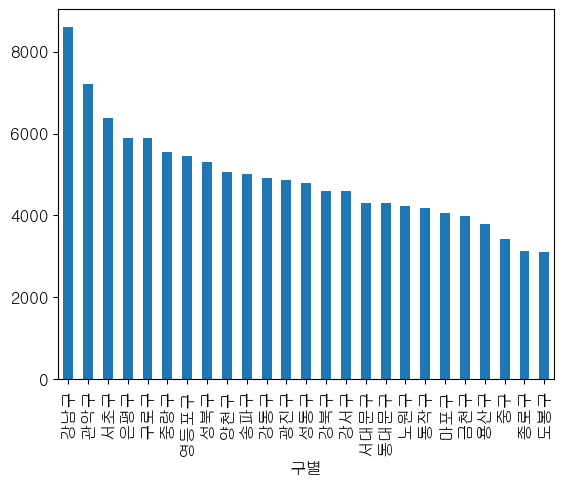

In [87]:
CCTV_POP['CCTV총계'].sort_values(ascending=False).plot(kind='bar')
plt.show()

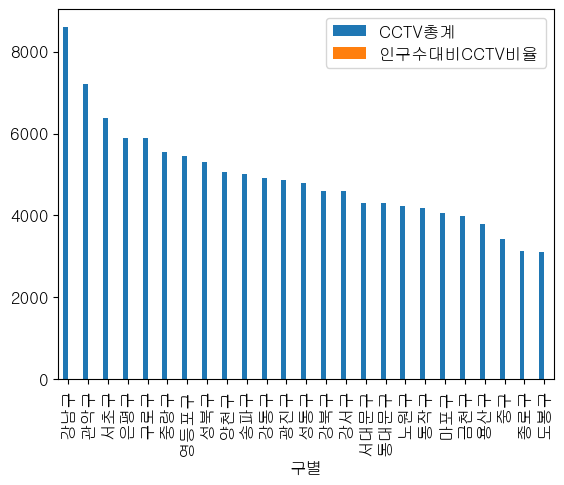

In [90]:
CCTV_POP[['CCTV총계', '인구수대비CCTV비율']].sort_values('CCTV총계', ascending=False).plot(kind='bar')
plt.show()
# 값 차이가 많이 남.

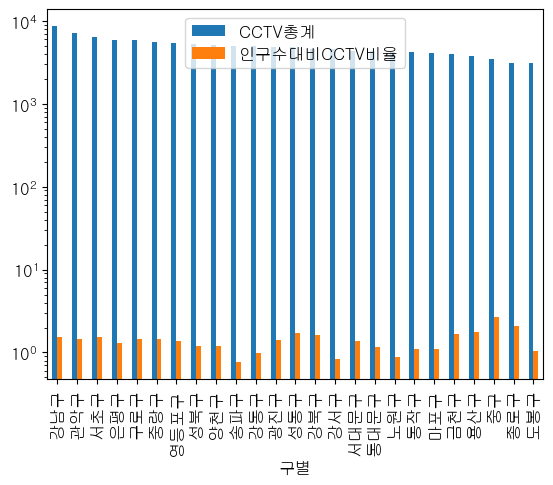

In [91]:
CCTV_POP[['CCTV총계', '인구수대비CCTV비율']].sort_values('CCTV총계', ascending=False).plot(kind='bar')
plt.yscale('log')
plt.show()

## 산포도(Scatter) 그리기

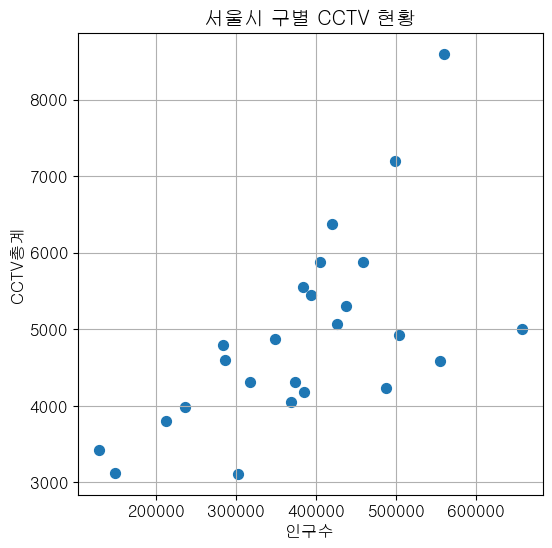

In [97]:
plt.figure(figsize=(6,6), dpi=100)
plt.scatter(CCTV_POP['인구수'], CCTV_POP['CCTV총계'], s=50)
plt.xlabel('인구수')
plt.ylabel('CCTV총계')
plt.grid()
plt.title('서울시 구별 CCTV 현황')
plt.show()

## 경향성 그리기

In [106]:
fp1 = np.polyfit(CCTV_POP['인구수'], CCTV_POP['CCTV총계'], 1)

In [107]:
fp1

array([6.07236533e-03, 2.58056531e+03])

In [108]:
f1 = np.poly1d(fp1)

In [109]:
f1(10000)

np.float64(2641.2889589231645)

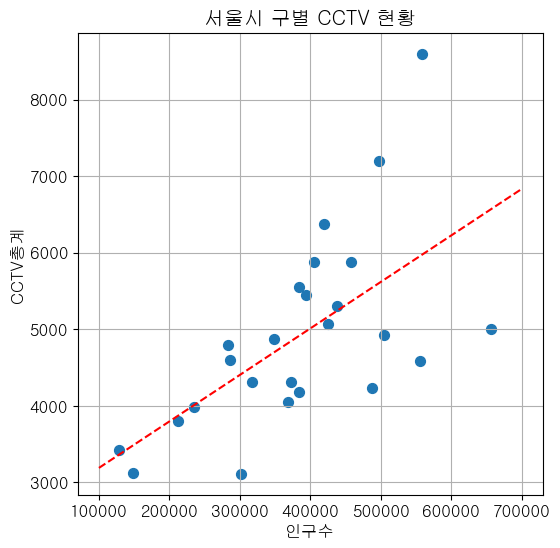

In [110]:
plt.figure(figsize=(6,6), dpi=100)
plt.scatter(CCTV_POP['인구수'], CCTV_POP['CCTV총계'], s=50)
plt.plot([100000, 700000], f1([100000, 700000]), 'r--')
plt.xlabel('인구수')
plt.ylabel('CCTV총계')
plt.grid()
plt.title('서울시 구별 CCTV 현황')
plt.show()

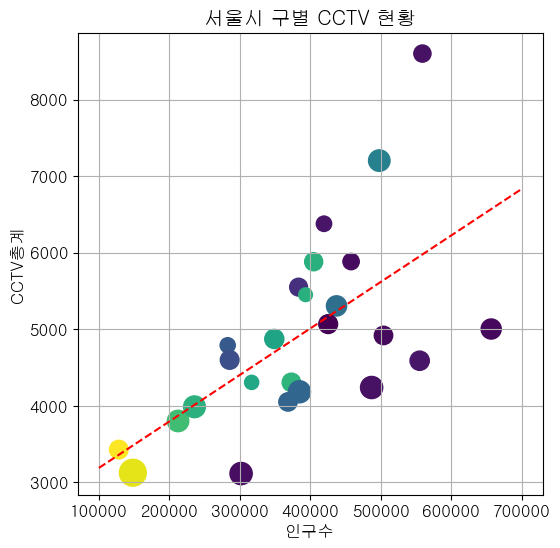

In [111]:
plt.figure(figsize=(6,6), dpi=100)
plt.scatter(CCTV_POP['인구수'], CCTV_POP['CCTV총계'], s=CCTV_POP['최근증가율']*5, c=CCTV_POP['외국인비율'])
plt.plot([100000, 700000], f1([100000, 700000]), 'r--')
plt.xlabel('인구수')
plt.ylabel('CCTV총계')
plt.grid()
plt.title('서울시 구별 CCTV 현황')
plt.show()

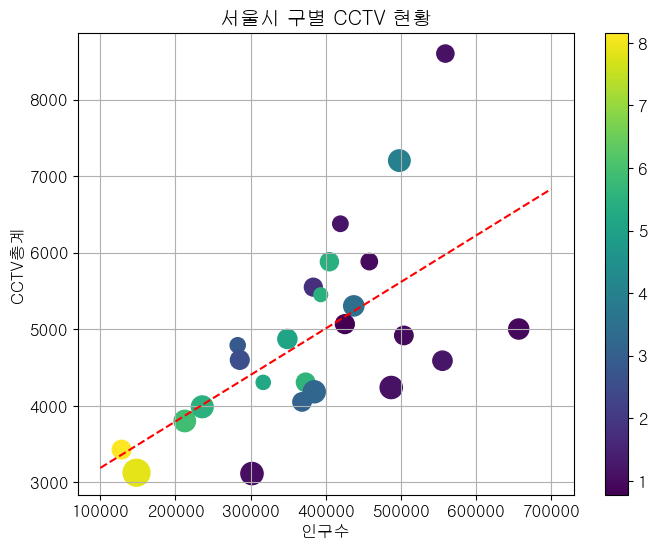

In [112]:
plt.figure(figsize=(8,6), dpi=100)
plt.scatter(CCTV_POP['인구수'], CCTV_POP['CCTV총계'], s=CCTV_POP['최근증가율']*5, c=CCTV_POP['외국인비율'])
plt.plot([100000, 700000], f1([100000, 700000]), 'r--')
plt.xlabel('인구수')
plt.ylabel('CCTV총계')
plt.colorbar()
plt.grid()
plt.title('서울시 구별 CCTV 현황')
plt.show()

In [114]:
CCTV_POP.index

Index(['종로구', '중구', '용산구', '성동구', '광진구', '동대문구', '중랑구', '성북구', '강북구', '도봉구',
       '노원구', '은평구', '서대문구', '마포구', '양천구', '강서구', '구로구', '금천구', '영등포구', '동작구',
       '관악구', '서초구', '강남구', '송파구', '강동구'],
      dtype='object', name='구별')

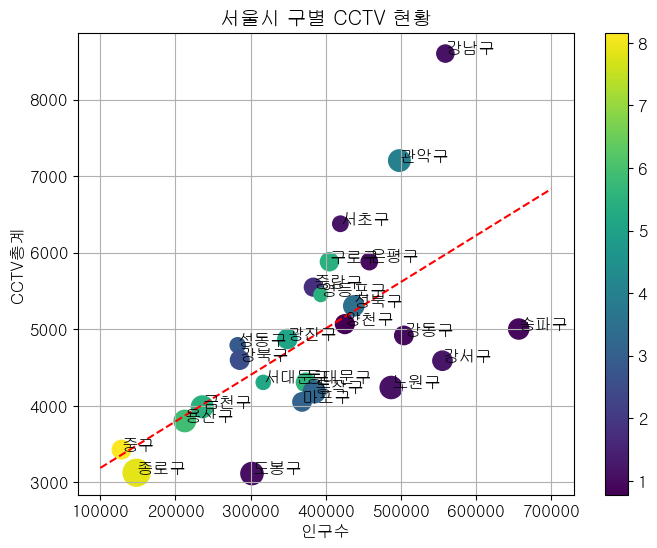

In [117]:
plt.figure(figsize=(8,6), dpi=100)
plt.scatter(CCTV_POP['인구수'], CCTV_POP['CCTV총계'], s=CCTV_POP['최근증가율']*5, c=CCTV_POP['외국인비율'])

for guName in CCTV_POP.index:
    x = CCTV_POP.at[guName, '인구수']
    y = CCTV_POP.at[guName, 'CCTV총계']
    plt.text(x, y, guName)

plt.plot([100000, 700000], f1([100000, 700000]), 'r--')
plt.xlabel('인구수')
plt.ylabel('CCTV총계')
plt.colorbar()
plt.grid()
plt.title('서울시 구별 CCTV 현황')
plt.savefig('서울시 구별 CCTV 현황', dpi=200) # 파일로 저장
plt.show()

In [116]:
CCTV_POP.to_excel('CCTV_POP.xlsx') # xlsx(excel) 파일로 저장.